<a href="https://colab.research.google.com/github/benplic/quantum-computing-learning/blob/main/notebooks/quantum_phase_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The Beginning**

In order to understand phase estimation I first had to understand Spectral Theorem because the two are related in a fascinating way. While there is more to it, the most important implication of spectral theorem is this:

> Given a square matrix $U$ with dimensions $N×N$, there exists some orthonormal basis $\{\vert \psi _1\rangle…\vert\psi_N\rangle\}$ of vectors along with complex numbers $\lambda_1=e^{2πi\theta_1} \dots \lambda_N=e^{2πiθ_N}$ such that $U=∑_{k=1}^N λ_k\vert \psi_k \rangle \langle \psi_k \vert$

This is the spectral decomposition, and this shows that each vector $\vert\psi_k\rangle$ is an eigenvector of $U$ with an eigenvalue of $\lambda_k$. That is to say, $$U\vert \psi_k \rangle = e^{2πi\theta_k}$$



**The Phase Estimation Problem**

Given a description of a quantum circuit, $U$, on n qubits and an n-qubit quantum state $\vert\psi\rangle$, and knowing that $\vert\psi\rangle$ is an eigenvalue of $U$, approximate the number $θ \in [0,1)$ satisfying $U\vert\psi\rangle = e^{2πi\theta}\vert\psi\rangle$.

Since standard phases range over $θ \in [0,1)$, adding in $\theta$ allows for a binary fraction output by a program to estimate a specific phase.

$$\theta = 0.\theta_1 \theta_2 \theta_3 …= \sum_{k=1}^{\infty} \theta_k 2^{-k}, \quad \theta_k \in \{0, 1\}$$

In [1]:
!pip install qiskit qiskit-aer

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

def bitstring_to_phase(bitstring: str, t:int) -> float:
  decimal = int(bitstring, 2)
  return decimal/(2**t)

In [3]:
#Set counting register size
t = 4
#Set test phase
theta = 0.37
#create circuit
counting = QuantumRegister(t,"c")
target = QuantumRegister(1,"t")
measure = ClassicalRegister(t,"m")
qc = QuantumCircuit(counting,target,measure)

#step 1: intitialize circuit
for qubit in counting:
  qc.h(qubit)

for qubit in target:
  qc.x(qubit)

#step 2: phase kickback
for j in range(t):
  #calculate scaled angle for 2^j to conserve resources
  angle = 2 * np.pi * theta * (2**j)

  #apply gate
  qc.cp(angle,counting[j],target[0])

#step 3: recovery (inverse QFT)
inverseQFT = QFT(t,do_swaps=True,inverse=True)

qc.append(inverseQFT,counting)

#step 4: measure
qc.measure(counting,measure)

print(qc.draw("text"))

     ┌───┐                                                ┌───────┐┌─┐         
c_0: ┤ H ├─■──────────────────────────────────────────────┤0      ├┤M├─────────
     ├───┤ │                                              │       │└╥┘┌─┐      
c_1: ┤ H ├─┼───────────■──────────────────────────────────┤1      ├─╫─┤M├──────
     ├───┤ │           │                                  │  IQFT │ ║ └╥┘┌─┐   
c_2: ┤ H ├─┼───────────┼───────────■──────────────────────┤2      ├─╫──╫─┤M├───
     ├───┤ │           │           │                      │       │ ║  ║ └╥┘┌─┐
c_3: ┤ H ├─┼───────────┼───────────┼───────────■──────────┤3      ├─╫──╫──╫─┤M├
     ├───┤ │P(2.3248)  │P(4.6496)  │P(9.2991)  │P(18.598) └───────┘ ║  ║  ║ └╥┘
  t: ┤ X ├─■───────────■───────────■───────────■────────────────────╫──╫──╫──╫─
     └───┘                                                          ║  ║  ║  ║ 
m: 4/═══════════════════════════════════════════════════════════════╩══╩══╩══╩═
                                        

/tmp/ipykernel_20843/4017137221.py:27: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  inverseQFT = QFT(t,do_swaps=True,inverse=True)


The most common output is 0110, which corresponds to 0.0110 = 0.375.
This value differs from the true angle, 0.37, by 0.0050000000000000044 or 1.3513513513513526%.


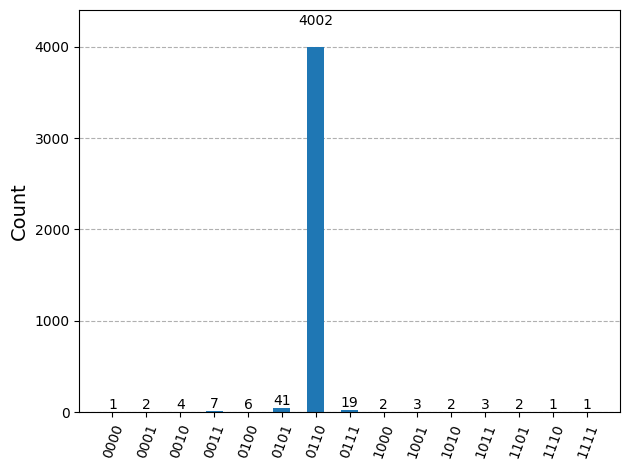

In [4]:
#Simulate!
backend = AerSimulator()

#pass manager to transpile my circuit for simulator
pm = generate_preset_pass_manager(backend=backend,optimization_level=1)
transpiled_circuit = pm.run(qc)

#run it!
job = backend.run(transpiled_circuit, shots= 4096)
result = job.result()

counts = result.get_counts()

bitstring = max(counts, key=counts.get)
fraction = bitstring_to_phase(bitstring,t)
error = abs(theta-fraction)

print(f"The most common output is {bitstring}, which corresponds to 0.{bitstring} = {fraction}.\nThis value differs from the true angle, {theta}, by {error} or {(error/theta)*100}%.")
plot_histogram(counts)